In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
import random
import csv
import warnings

from DCmatch import Match
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter("ignore", pd.errors.SettingWithCopyWarning)

In [3]:
folder = os.fsencode("seasons/bettingSeasons")
dataframes = []
for file in sorted(os.listdir(folder)):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        print(filename)
        df = pd.read_csv("seasons/bettingSeasons/" + filename)
        dataframes.append(df)

data = pd.concat(dataframes, axis=0)

1920-Copy1.csv
2021-Copy1.csv
2122-Copy1.csv
2223-Copy1.csv
2324-Copy1.csv
2425-Copy1.csv
E0 (1).csv


In [5]:
data = data[[
    "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "HS", "AS", "HST", "AST", 
    "B365H", "B365D", "B365A", "MaxH", "MaxD", "MaxA", "Max>2.5", "Max<2.5"
]]

In [7]:
uniqueTeams = data["HomeTeam"].unique()
teamsIndex = {}
for i in range(len(uniqueTeams)):
    teamsIndex[uniqueTeams[i]] = i
teamsIndex

{'Liverpool': 0,
 'West Ham': 1,
 'Bournemouth': 2,
 'Burnley': 3,
 'Crystal Palace': 4,
 'Watford': 5,
 'Tottenham': 6,
 'Leicester': 7,
 'Newcastle': 8,
 'Man United': 9,
 'Arsenal': 10,
 'Aston Villa': 11,
 'Brighton': 12,
 'Everton': 13,
 'Norwich': 14,
 'Southampton': 15,
 'Man City': 16,
 'Sheffield United': 17,
 'Chelsea': 18,
 'Wolves': 19,
 'Fulham': 20,
 'West Brom': 21,
 'Leeds': 22,
 'Brentford': 23,
 "Nott'm Forest": 24,
 'Luton': 25,
 'Ipswich': 26,
 'Sunderland': 27}

In [9]:
estimatesAtTimeT = []

with open("newEstimatesOvernight.csv", newline="") as my_csv:
    csvReader = csv.reader(my_csv)
    for row in csvReader:
        estimatesAtTimeT.append([float(x) for x in row])
        
strengthsOverTime = [[row[i] for row in estimatesAtTimeT] for i in range(len(estimatesAtTimeT[0]))]

In [11]:
teamStrengths = [[] for i in range(58)]

for i in range(len(data["AwayTeam"])):
    if i < 200:
        for j in range(58):
            teamStrengths[j].append(0)
    else:
        for j in range(58):
            teamStrengths[j].append(strengthsOverTime[j][(i-380) // 10])

In [13]:
attack = teamStrengths[0:28]
defence = teamStrengths[28:56]
homeAdvantage = teamStrengths[-2]
rho = teamStrengths[-1]
len(homeAdvantage)

2490

In [15]:
home_idx = data["HomeTeam"].map(teamsIndex).to_numpy()
away_idx = data["AwayTeam"].map(teamsIndex).to_numpy()

In [17]:
homeAttacks = []
homeDefences = []
awayAttacks = []
awayDefences = []

for i in range(len(data["HomeTeam"])):
    homeAttacks.append(attack[home_idx[i]][i])
    homeDefences.append(defence[home_idx[i]][i])
    awayAttacks.append(attack[away_idx[i]][i])
    awayDefences.append(defence[away_idx[i]][i])

homeProbs = []
drawProbs = []
awayProbs = []
over2_5s = []
under2_5s = []

for i in range(len(data["HomeTeam"])):
    thisMatch = Match(homeAttacks[i], homeDefences[i], awayAttacks[i], awayDefences[i], homeAdvantage[i], rho[i], 8)
    outcomes = thisMatch.getOutcomeProbs()
    homeProbs.append(outcomes[0])
    drawProbs.append(outcomes[1])
    awayProbs.append(outcomes[2])
    scores = thisMatch.getScoreMatrix()
    over2_5 = 0
    under2_5 = 0
    for i in range(len(scores)):
        for j in range(len(scores[i])):
            if (i + j) > 2:
                over2_5 += scores[i][j]
            else:
                under2_5 += scores[i][j]

    over2_5s.append(over2_5)
    under2_5s.append(under2_5)

data["attackH"]  = homeAttacks
data["defenceH"] = homeDefences
data["attackA"]  = awayAttacks
data["defenceA"] = awayDefences
data["rho"] = rho
data["homeAdv"] = homeAdvantage
data["homeProb"] = homeProbs
data["drawProb"] = drawProbs
data["awayProb"] = awayProbs
data["FairHomeOdds"] = 1 / data["homeProb"]
data["FairDrawOdds"] = 1 / data["drawProb"]
data["FairAwayOdds"] = 1 / data["awayProb"]
data["Over2.5Prob"] = over2_5s
data["Under2.5Prob"] = under2_5s
data["FairOver2.5"] = 1 / data["Over2.5Prob"]
data["FairUnder2.5"] = 1 / data["Under2.5Prob"]


In [19]:
data.tail()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,...,homeProb,drawProb,awayProb,FairHomeOdds,FairDrawOdds,FairAwayOdds,Over2.5Prob,Under2.5Prob,FairOver2.5,FairUnder2.5
205,07/01/2026,Fulham,Chelsea,2,1,H,16,14,5,6,...,0.291171,0.290571,0.418258,3.434406,3.441499,2.390870,0.472389,0.527611,2.116899,1.895336
206,07/01/2026,Man City,Brighton,1,1,D,22,6,6,3,...,0.656030,0.204461,0.139509,1.524320,4.890905,7.168008,0.634727,0.365273,1.575481,2.737677
207,07/01/2026,Burnley,Man United,2,2,D,7,30,1,10,...,0.231094,0.261518,0.507388,4.327244,3.823833,1.970877,0.541774,0.458226,1.845789,2.182328
208,07/01/2026,Newcastle,Leeds,4,3,H,18,14,8,6,...,0.541279,0.256111,0.202610,1.847475,3.904555,4.935602,0.532644,0.467356,1.877426,2.139698
209,08/01/2026,Arsenal,Liverpool,0,0,D,9,8,4,0,...,0.594981,0.239418,0.165601,1.680725,4.176798,6.038622,0.544806,0.455194,1.835517,2.196864


In [21]:
bettingFrame = data.tail(n=2180)
bettingFrame["HomeWin"] = np.where(bettingFrame["FTR"] == "H", 1, 0)
bettingFrame["Draw"] = np.where(bettingFrame["FTR"] == "D", 1, 0)
bettingFrame["AwayWin"] = np.where(bettingFrame["FTR"] == "A", 1, 0)
bettingFrame["Over2.5"] = np.where(bettingFrame["FTHG"] + bettingFrame["FTAG"] > 2, 1, 0)
bettingFrame["Under2.5"] = np.where(bettingFrame["FTHG"] + bettingFrame["FTAG"] < 3, 1, 0)
bettingFrame.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,...,FairAwayOdds,Over2.5Prob,Under2.5Prob,FairOver2.5,FairUnder2.5,HomeWin,Draw,AwayWin,Over2.5,Under2.5
310,27/06/2020,Aston Villa,Wolves,0,1,A,11,9,1,2,...,9.099736,0.468080,0.531920,2.136387,1.879982,0,0,1,0,1
311,28/06/2020,Watford,Southampton,1,3,A,8,11,0,7,...,16.288586,0.775216,0.224784,1.289962,4.448725,0,0,1,1,0
312,29/06/2020,Crystal Palace,Burnley,0,1,A,17,8,4,4,...,7.523964,0.556343,0.443657,1.797451,2.253996,0,0,1,0,1
313,30/06/2020,Brighton,Man United,0,3,A,8,12,2,6,...,3.577605,0.666086,0.333914,1.501308,2.994783,0,0,1,1,0
314,01/07/2020,Arsenal,Norwich,4,0,H,13,8,8,2,...,6.306134,0.495682,0.504318,2.017423,1.982875,1,0,0,1,0


In [23]:
bettingFrame["impO_raw"] = 1 / bettingFrame["Max>2.5"]
bettingFrame["impU_raw"] = 1 / bettingFrame["Max<2.5"]

In [25]:
bettingFrame["overround"] = (
    bettingFrame["impO_raw"] +
    bettingFrame["impU_raw"]
)

bettingFrame["impO"] = bettingFrame["impO_raw"] / bettingFrame["overround"]
bettingFrame["impU"] = bettingFrame["impU_raw"] / bettingFrame["overround"]

In [27]:
bettingFrame["Brier"] = (bettingFrame["Over2.5Prob"] - bettingFrame["Over2.5"])**2

In [29]:
np.sum(bettingFrame.Brier)/len(np.array(bettingFrame.Brier))

0.2520524864566764

In [31]:
bettingFrame["LogLoss"] = bettingFrame["Over2.5"]*np.log(bettingFrame["Over2.5Prob"]) + (1 - bettingFrame["Over2.5"])*np.log(1-bettingFrame["Over2.5Prob"])

In [33]:
-np.sum(bettingFrame.LogLoss)/len(np.array(bettingFrame.LogLoss))

0.7017004789753171

In [35]:
bettingFrame["0.5Brier"] = (0.5 - bettingFrame["Over2.5"])**2

In [37]:
np.sum(bettingFrame[["0.5Brier"]])/len(np.array(bettingFrame[["0.5Brier"]]))

0.5Brier    0.25
dtype: float64

In [39]:
bettingFrame["0.5LogLoss"] = bettingFrame["Over2.5"]*np.log(0.5) + (1 - bettingFrame["Over2.5"])*np.log(0.5)

In [41]:
-np.sum(bettingFrame[["0.5LogLoss"]])/len(np.array(bettingFrame[["0.5LogLoss"]]))

0.5LogLoss    0.693147
dtype: float64

In [43]:
bettingFrame["impBrier"] = (bettingFrame["impO"] - bettingFrame["Over2.5"])**2

In [45]:
np.sum(bettingFrame.impBrier)/len(np.array(bettingFrame.impBrier))

0.24038394467883697

In [47]:
bettingFrame["impLogLoss"] = bettingFrame["Over2.5"]*np.log(bettingFrame["impO"]) + (1 - bettingFrame["Over2.5"])*np.log(1-bettingFrame["impO"])

In [49]:
-np.sum(bettingFrame.impLogLoss)/len(np.array(bettingFrame.impLogLoss))

0.6735484702584323

In [51]:
bettingFrame[["Over2.5", "Under2.5"]].describe()

,Over2.5,Under2.5
count,2180.000000,2180.000000
mean,0.555046,0.444954
std,0.497075,0.497075
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,0.000000
75%,1.000000,1.000000
max,1.000000,1.000000


In [53]:
bettingFrame["rateBrier"] = (0.555046 - bettingFrame["Over2.5"])**2

In [55]:
np.sum(bettingFrame.rateBrier)/len(np.array(bettingFrame.rateBrier))

0.24696995202425695

In [57]:
bettingFrame["rateLogLoss"] = bettingFrame["Over2.5"]*np.log(0.555046) + (1 - bettingFrame["Over2.5"])*np.log(1-0.555046)

In [59]:
-np.sum(bettingFrame.rateLogLoss)/len(np.array(bettingFrame.rateLogLoss))

0.6870747832843802

In [61]:
bettingFrame["ValueOver2.5"] = bettingFrame["Max>2.5"] * bettingFrame["Over2.5Prob"]
bettingFrame["ValueUnder2.5"] = bettingFrame["Max<2.5"] * bettingFrame["Under2.5Prob"]

In [63]:
bettingFrame["OverBet"] = np.where(bettingFrame["ValueOver2.5"] > 1.1, 1, 0)
bettingFrame["UnderBet"] = np.where(bettingFrame["ValueUnder2.5"] > 1.1, 1, 0)

In [65]:
bettingFrame["ProfitO/U"] = bettingFrame["Over2.5"] * bettingFrame["OverBet"] * bettingFrame["Max>2.5"] + bettingFrame["Under2.5"] * bettingFrame["UnderBet"] * bettingFrame["Max<2.5"] - (bettingFrame["OverBet"] + bettingFrame["UnderBet"])

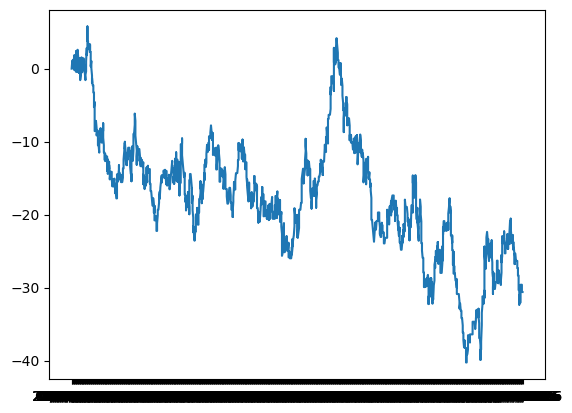

In [67]:
fig, ax = plt.subplots()
ax.plot(bettingFrame["Date"], bettingFrame["ProfitO/U"].cumsum())

In [75]:
bankroll = 1000
kellyFraction = 0.25

bettingFrame["kellyOverbetFraction"] = bettingFrame["OverBet"] * (bettingFrame["Over2.5Prob"] * (bettingFrame["Max>2.5"] - 1) - (1-bettingFrame["Over2.5Prob"])) / ((bettingFrame["Max>2.5"] - 1)) * kellyFraction
bettingFrame["kellyUnderbetFraction"] = bettingFrame["UnderBet"] * (bettingFrame["Under2.5Prob"] * (bettingFrame["Max<2.5"] - 1) - (1-bettingFrame["Under2.5Prob"])) / ((bettingFrame["Max<2.5"] - 1)) * kellyFraction

bettingFrame["kellyOverbet"] = bettingFrame["OverBet"] * (bettingFrame["Over2.5Prob"] * (bettingFrame["Max>2.5"] - 1) - (1-bettingFrame["Over2.5Prob"])) / ((bettingFrame["Max>2.5"] - 1))
bettingFrame["kellyUnderbet"] = bettingFrame["UnderBet"] * (bettingFrame["Under2.5Prob"] * (bettingFrame["Max<2.5"] - 1) - (1-bettingFrame["Under2.5Prob"])) / ((bettingFrame["Max<2.5"] - 1))

In [77]:
starting_bankroll = 100
bankroll = starting_bankroll

bankroll_history = []
stake_history = []
pnl_history = []

kellyBank = 100
kellyBankroll = []
kellyStakes = []
kellyPnL = []

for _, row in bettingFrame.iterrows():

    stake = 0.0
    pnl = 0.0

    kellyStake = 0.0
    kellyPnLs = 0.0
    
    # Home bet
    if row['OverBet'] == 1:
        stake = bankroll * row['kellyOverbetFraction']
        kellyStake = kellyBank * row["kellyOverbet"]
        if row['Over2.5'] == 1:
            pnl = stake * (row['Max>2.5'] - 1)
            kellyPnLs = kellyStake * (row['Max>2.5'] - 1)
        else:
            pnl = -stake
            kellyPnLs = -kellyStake

    # Away bet
    elif row['UnderBet'] == 1:
        stake = bankroll * row['kellyUnderbetFraction']
        kellyStake = kellyBank * row["kellyUnderbet"]
        if row['Under2.5'] == 1:
            pnl = stake * (row['Max<2.5'] - 1)
            kellyPnLs = kellyStake * (row['Max<2.5'] - 1)
        else:
            pnl = -stake
            kellyPnLs = -kellyStake

    bankroll += pnl
    kellyBank += kellyPnLs

    bankroll_history.append(bankroll)
    stake_history.append(stake)
    pnl_history.append(pnl)

    kellyBankroll.append(kellyBank)
    kellyStakes.append(kellyStake)
    kellyPnL.append(kellyPnLs)

bettingFrame['Bankroll'] = bankroll_history
bettingFrame['Stake'] = stake_history
bettingFrame['PnL'] = pnl_history

bettingFrame['kellyBankroll'] = kellyBankroll
bettingFrame['kellyStake'] = kellyStakes
bettingFrame['kellyPnL'] = kellyPnL

In [83]:
bettingFrame = bettingFrame.reset_index()
bettingFrame.drop(["index"], axis=1)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,...,kellyOverbetFraction,kellyUnderbetFraction,Bankroll,Stake,PnL,kellyOverbet,kellyUnderbet,kellyBankroll,kellyStake,kellyPnL
0,27/06/2020,Aston Villa,Wolves,0,1,A,11,9,1,2,...,0.000000,-0.000000,100.000000,0.000000,0.000000,0.000000,-0.000000,1.000000e+02,0.000000,0.000000
1,28/06/2020,Watford,Southampton,1,3,A,8,11,0,7,...,0.142717,-0.000000,115.698866,14.271696,15.698866,0.570868,-0.000000,1.627955e+02,57.086785,62.795463
2,29/06/2020,Crystal Palace,Burnley,0,1,A,17,8,4,4,...,0.071040,-0.000000,107.479574,8.219292,-8.219292,0.284162,-0.000000,1.165353e+02,46.260208,-46.260208
3,30/06/2020,Brighton,Man United,0,3,A,8,12,2,6,...,0.096371,-0.000000,119.805553,10.357965,12.325979,0.385486,-0.000000,1.699933e+02,44.922698,53.458010
4,01/07/2020,Arsenal,Norwich,4,0,H,13,8,8,2,...,-0.000000,0.029267,116.299242,3.506310,-3.506310,-0.000000,0.117067,1.500927e+02,19.900552,-19.900552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2175,07/01/2026,Fulham,Chelsea,2,1,H,16,14,5,6,...,-0.000000,0.000000,1.449617,0.000000,0.000000,-0.000000,0.000000,1.797740e-23,0.000000,0.000000
2176,07/01/2026,Man City,Brighton,1,1,D,22,6,6,3,...,-0.000000,0.000000,1.449617,0.000000,0.000000,-0.000000,0.000000,1.797740e-23,0.000000,0.000000
2177,07/01/2026,Burnley,Man United,2,2,D,7,30,1,10,...,-0.000000,-0.000000,1.449617,0.000000,0.000000,-0.000000,-0.000000,1.797740e-23,0.000000,0.000000
2178,07/01/2026,Newcastle,Leeds,4,3,H,18,14,8,6,...,-0.000000,-0.000000,1.449617,0.000000,0.000000,-0.000000,-0.000000,1.797740e-23,0.000000,0.000000


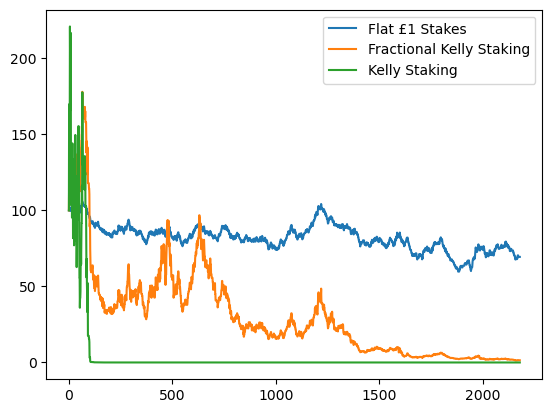

In [85]:
fig, ax = plt.subplots()
ax.plot(bettingFrame["ProfitO/U"].cumsum()+100, label="Flat £1 Stakes")
ax.plot(bettingFrame["Bankroll"], label="Fractional Kelly Staking")
ax.plot(bettingFrame["kellyBankroll"], label="Kelly Staking")
ax.legend()
plt.savefig("OU.pdf")

In [103]:
bettingFrame.kellyStake.sum()

1766.4563900887129

In [105]:
bettingFrame["kellyPnL"].sum()

-99.99999999999997

In [107]:
-100/1766.456

-0.056610524122876545

In [109]:
np.var(bettingFrame["kellyPnL"])

33.297742448945954

In [45]:
bettingFrame["OverPredicted"] = np.where(bettingFrame["Over2.5Prob"] > 0.5, 1, 0)
bettingFrame["UnderPredicted"] = np.where(bettingFrame["Under2.5Prob"] > 0.5, 1, 0)

/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_63849/168256885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bettingFrame["OverPredicted"] = np.where(bettingFrame["Over2.5Prob"] > 0.5, 1, 0)
/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_63849/168256885.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bettingFrame["UnderPredicted"] = np.where(bettingFrame["Under2.5Prob"] > 0.5, 1, 0)


In [49]:
bettingFrame["CorrectPrediction"] = np.where(bettingFrame["OverPredicted"] == bettingFrame["Over2.5"], 1, 0)

/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_63849/2707364504.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bettingFrame["CorrectPrediction"] = np.where(bettingFrame["OverPredicted"] == bettingFrame["Over2.5"], 1, 0)


In [51]:
np.mean(bettingFrame.CorrectPrediction)

0.5655963302752294

In [64]:
bettingFrame["Brier"] = (bettingFrame["Under2.5Prob"] - bettingFrame["Under2.5"])**2

/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_63849/3035002801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bettingFrame["Brier"] = (bettingFrame["Under2.5Prob"] - bettingFrame["Under2.5"])**2


In [66]:
np.sum(bettingFrame.Brier)/len(np.array(bettingFrame.Brier))

0.2520524864566764

In [62]:
bettingFrame[["Over2.5", "Under2.5", "OverPredicted", "UnderPredicted"]].describe()

,Over2.5,Under2.5,OverPredicted,UnderPredicted
count,2180.000000,2180.000000,2180.000000,2180.000000
mean,0.555046,0.444954,0.618807,0.381193
std,0.497075,0.497075,0.485791,0.485791
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [225]:
bettingFrame.OverBet.sum() + bettingFrame.UnderBet.sum()

2078

In [227]:
bettingFrame["ProfitO/U"].sum()

-55.210000000000036

In [229]:
cleanProfits = [x for x in bettingFrame["ProfitO/U"] if x!=0]

In [231]:
np.mean(cleanProfits)

-0.026632899179932477

In [233]:
np.var(cleanProfits)

1.136842304696708

In [235]:
import csv


with open("profitsBTTS.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(cleanProfits)

In [237]:
bettingFrame.columns

Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'AS',
       'HST', 'AST', 'B365H', 'B365D', 'B365A', 'MaxH', 'MaxD', 'MaxA', 'AvgH',
       'AvgD', 'AvgA', 'Max>2.5', 'Max<2.5', 'attackH', 'defenceH', 'attackA',
       'defenceA', 'rho', 'homeAdv', 'homeProb', 'drawProb', 'awayProb',
       'FairHomeOdds', 'FairDrawOdds', 'FairAwayOdds', 'Over2.5Prob',
       'Under2.5Prob', 'FairOver2.5', 'FairUnder2.5', 'HomeWin', 'Draw',
       'AwayWin', 'Over2.5', 'Under2.5', 'ValueRatioHome', 'ValueRatioDraw',
       'ValueRatioAway', 'ValueOver2.5', 'ValueUnder2.5', 'HomeBet', 'AwayBet',
       'DrawBet', 'OverBet', 'UnderBet', 'Profit1X2', 'ProfitO/U'],
      dtype='object')

In [239]:
bettingFrame = bettingFrame[[
    "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG",
    "FTR", "Max>2.5", "Max<2.5", "Over2.5Prob", "Under2.5Prob",
    "FairOver2.5", "FairUnder2.5", "Over2.5", "Under2.5",
    "ValueOver2.5", "ValueUnder2.5", "OverBet", "UnderBet", "ProfitO/U"
]]

In [241]:
bettingFrame.tail()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Max>2.5,Max<2.5,Over2.5Prob,Under2.5Prob,FairOver2.5,FairUnder2.5,Over2.5,Under2.5,ValueOver2.5,ValueUnder2.5,OverBet,UnderBet,ProfitO/U
95,01/11/2025,Tottenham,Chelsea,0,1,A,1.75,2.12,0.624302,0.375698,1.601789,2.661713,0,1,1.092529,0.796480,1,0,-1.00
96,01/11/2025,Liverpool,Aston Villa,2,0,H,1.56,2.50,0.603967,0.396033,1.655721,2.525039,0,1,0.942188,0.990084,0,0,0.00
97,02/11/2025,West Ham,Newcastle,3,1,H,1.80,2.17,0.609663,0.390337,1.640251,2.561886,1,0,1.097393,0.847032,1,0,0.80
98,02/11/2025,Man City,Bournemouth,3,1,H,1.55,2.55,0.685857,0.314143,1.458029,3.183267,1,0,1.063079,0.801064,1,0,0.55
99,03/11/2025,Sunderland,Everton,1,1,D,2.38,1.62,0.279182,0.720818,3.581889,1.387313,0,1,0.664454,1.167725,0,1,0.62


### Beginning Of CHATGPT

In [152]:
df = bettingFrame.copy()

df = df[df["ProfitO/U"] != 0]


In [154]:
over_df = df[df["OverBet"] == 1].copy()

over_df["side"] = "Over"
over_df["model_prob"] = over_df["Over2.5Prob"]
over_df["market_odds"] = over_df["Max>2.5"]
over_df["value_ratio"] = over_df["ValueOver2.5"]

In [156]:
under_df = df[df["UnderBet"] == 1].copy()

under_df["side"] = "Under"
under_df["model_prob"] = under_df["Under2.5Prob"]
under_df["market_odds"] = under_df["Max<2.5"]
under_df["value_ratio"] = under_df["ValueUnder2.5"]

In [158]:
bets = pd.concat([over_df, under_df], ignore_index=True)

In [160]:
bets

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Max>2.5,Max<2.5,Over2.5Prob,Under2.5Prob,...,Under2.5,ValueOver2.5,ValueUnder2.5,OverBet,UnderBet,ProfitO/U,side,model_prob,market_odds,value_ratio
0,01/01/2020,Burnley,Aston Villa,1,2,A,1.93,2.03,0.521849,0.478151,...,0,1.007169,0.970646,1,0,0.93,Over,0.521849,1.93,1.007169
1,01/01/2020,Newcastle,Leicester,0,3,A,2.01,1.99,0.583848,0.416152,...,0,1.173535,0.828142,1,0,1.01,Over,0.583848,2.01,1.173535
2,01/01/2020,Southampton,Tottenham,1,0,H,1.70,2.33,0.714920,0.285080,...,1,1.215364,0.664236,1,0,-1.00,Over,0.714920,1.70,1.215364
3,01/01/2020,Man City,Everton,2,1,H,1.41,3.20,0.730703,0.269297,...,0,1.030291,0.861751,1,0,0.41,Over,0.730703,1.41,1.030291
4,11/01/2020,Leicester,Southampton,1,2,A,1.69,2.39,0.683140,0.316860,...,0,1.154507,0.757295,1,0,0.69,Over,0.683140,1.69,1.154507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2073,25/10/2025,Brentford,Liverpool,3,2,H,1.58,2.50,0.594254,0.405746,...,0,0.938921,1.014365,0,1,-1.00,Under,0.405746,2.50,1.014365
2074,26/10/2025,Wolves,Burnley,2,3,A,2.30,1.71,0.380705,0.619295,...,0,0.875622,1.058994,0,1,-1.00,Under,0.619295,1.71,1.058994
2075,01/11/2025,Burnley,Arsenal,0,2,A,1.80,2.14,0.488533,0.511467,...,1,0.879359,1.094540,0,1,1.14,Under,0.511467,2.14,1.094540
2076,01/11/2025,Crystal Palace,Brentford,2,0,H,1.80,2.10,0.493534,0.506466,...,1,0.888361,1.063579,0,1,1.10,Under,0.506466,2.10,1.063579


In [162]:
BANKROLL = 1000

bets["log_return"] = np.log1p(bets["ProfitO/U"] / BANKROLL)

In [164]:
prob_bins = np.arange(0.25, 0.80, 0.05)

bets["prob_bucket"] = pd.cut(
    bets["model_prob"],
    bins=prob_bins
)

In [166]:
def kelly_stats(x):
    g_per_bet = x["log_return"].mean()
    log_sd = x["log_return"].std()

    cum_log = x["log_return"].cumsum()
    drawdown = cum_log - cum_log.cummax()

    return pd.Series({
        "n_bets": len(x),
        "g_per_bet": g_per_bet,
        "g_annual": g_per_bet * 365,
        "log_return_sd": log_sd,
        "max_drawdown": drawdown.min()
    })

In [168]:
prob_bucket_stats = (
    bets
    .groupby("prob_bucket")
    .apply(kelly_stats)
    .reset_index()
)

/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_65390/3529162523.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("prob_bucket")
/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_65390/3529162523.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(kelly_stats)


In [174]:
value_bins = [1.00, 1.02, 1.04, 1.06, 1.10, 1.14, 1.18, np.inf]

bets["value_bucket"] = pd.cut(
    bets["value_ratio"],
    bins=value_bins
)

value_bucket_stats = (
    bets
    .groupby("value_bucket")
    .apply(kelly_stats)
    .reset_index()
)

/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_65390/3698973985.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("value_bucket")
/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_65390/3698973985.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(kelly_stats)


In [176]:
value_bucket_stats

,value_bucket,n_bets,g_per_bet,g_annual,log_return_sd,max_drawdown
0,"(1.0, 1.02]",184.0,-0.000046,-0.016636,0.000971,-0.015675
1,"(1.02, 1.04]",181.0,0.000014,0.005017,0.001011,-0.018335
2,"(1.04, 1.06]",203.0,0.000034,0.012376,0.001028,-0.014554
3,"(1.06, 1.1]",342.0,0.000085,0.030979,0.001005,-0.011234
4,"(1.1, 1.14]",271.0,-0.000131,-0.047666,0.001011,-0.049168
5,"(1.14, 1.18]",228.0,-0.000055,-0.020004,0.001052,-0.019278
6,"(1.18, inf]",669.0,-0.000056,-0.020517,0.001165,-0.060723


CONCLUSION: POTENTIAL VALUE IN [1.02,1.1] VALUE RANGE

In [251]:
filteredOver = bettingFrame.loc[
    (bettingFrame["ValueOver2.5"] > 1.02) &
    (bettingFrame["ValueOver2.5"] <= 1.10)
]
filteredUnder = bettingFrame.loc[
    (bettingFrame["ValueUnder2.5"] > 1.02) &
    (bettingFrame["ValueUnder2.5"] <= 1.10)
]

In [259]:
filteredOver

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Max>2.5,Max<2.5,Over2.5Prob,Under2.5Prob,FairOver2.5,FairUnder2.5,Over2.5,Under2.5,ValueOver2.5,ValueUnder2.5,OverBet,UnderBet,ProfitO/U
204,01/01/2020,Man City,Everton,2,1,H,1.41,3.20,0.730703,0.269297,1.368545,3.713371,1,0,1.030291,0.861751,1,0,0.41
215,11/01/2020,Wolves,Newcastle,1,1,D,2.10,1.87,0.498469,0.501531,2.006143,1.993895,0,1,1.046785,0.937863,1,0,-1.00
216,11/01/2020,Tottenham,Liverpool,0,1,A,1.67,2.41,0.641232,0.358768,1.559498,2.787316,0,1,1.070857,0.864631,1,0,-1.00
218,12/01/2020,Aston Villa,Man City,1,6,A,1.29,4.00,0.805822,0.194178,1.240969,5.149916,1,0,1.039510,0.776712,1,0,0.29
224,18/01/2020,Southampton,Wolves,2,3,A,2.10,1.86,0.518399,0.481601,1.929017,2.076407,1,0,1.088638,0.895778,1,0,1.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,26/10/2025,Bournemouth,Nott'm Forest,2,0,H,1.91,2.02,0.543866,0.456134,1.838688,2.192338,0,1,1.038784,0.921391,1,0,-1.00
90,01/11/2025,Brighton,Leeds,3,0,H,1.85,2.05,0.587624,0.412376,1.701768,2.424973,1,0,1.087105,0.845370,1,0,0.85
95,01/11/2025,Tottenham,Chelsea,0,1,A,1.75,2.12,0.624302,0.375698,1.601789,2.661713,0,1,1.092529,0.796480,1,0,-1.00
97,02/11/2025,West Ham,Newcastle,3,1,H,1.80,2.17,0.609663,0.390337,1.640251,2.561886,1,0,1.097393,0.847032,1,0,0.80


In [255]:
newBets = pd.concat([filteredOver, filteredUnder], ignore_index=True)

In [257]:
newBets

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Max>2.5,Max<2.5,Over2.5Prob,Under2.5Prob,FairOver2.5,FairUnder2.5,Over2.5,Under2.5,ValueOver2.5,ValueUnder2.5,OverBet,UnderBet,ProfitO/U
0,01/01/2020,Man City,Everton,2,1,H,1.41,3.20,0.730703,0.269297,1.368545,3.713371,1,0,1.030291,0.861751,1,0,0.41
1,11/01/2020,Wolves,Newcastle,1,1,D,2.10,1.87,0.498469,0.501531,2.006143,1.993895,0,1,1.046785,0.937863,1,0,-1.00
2,11/01/2020,Tottenham,Liverpool,0,1,A,1.67,2.41,0.641232,0.358768,1.559498,2.787316,0,1,1.070857,0.864631,1,0,-1.00
3,12/01/2020,Aston Villa,Man City,1,6,A,1.29,4.00,0.805822,0.194178,1.240969,5.149916,1,0,1.039510,0.776712,1,0,0.29
4,18/01/2020,Southampton,Wolves,2,3,A,2.10,1.86,0.518399,0.481601,1.929017,2.076407,1,0,1.088638,0.895778,1,0,1.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,05/10/2025,Aston Villa,Burnley,2,1,H,1.98,1.92,0.453697,0.546303,2.204114,1.830486,1,0,0.898320,1.048902,0,1,-1.00
722,05/10/2025,Everton,Crystal Palace,2,1,H,2.33,1.67,0.382147,0.617853,2.616796,1.618507,1,0,0.890402,1.031815,0,1,-1.00
723,26/10/2025,Wolves,Burnley,2,3,A,2.30,1.71,0.380705,0.619295,2.626704,1.614740,1,0,0.875622,1.058994,0,1,-1.00
724,01/11/2025,Burnley,Arsenal,0,2,A,1.80,2.14,0.488533,0.511467,2.046945,1.955160,0,1,0.879359,1.094540,0,1,1.14


In [267]:
cleanProfits = [x for x in newBets["ProfitO/U"] if x!=0]

In [269]:
np.mean(cleanProfits)

0.053402203856749306

In [271]:
np.var(cleanProfits)

1.0226637693615344

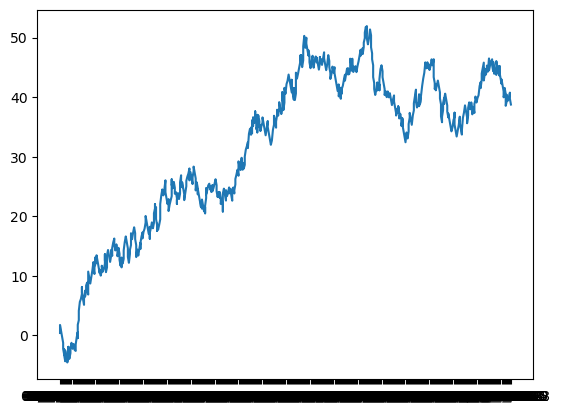

In [279]:
newBets = newBets.sort_values(by="Date")
fig, ax = plt.subplots()
ax.plot(newBets["Date"], newBets["ProfitO/U"].cumsum())